In [1]:
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import time
import STQP
import _separation 
from pydmd import DMD
from sklearn.metrics import mean_squared_error
import pickle
import os

In [2]:
# load video
input_path = "/Users/paodou/Desktop/SpDMD/code_github/Data/highway"
save_path = '/Users/paodou/Desktop/code_github/highway_results.pkl'

img_files = sorted(Path(input_path).glob("*.jpg"))
print(f"Total images: {len(img_files)}")

test_video = []
for img_file in img_files[:400]:
    img = cv2.imread(str(img_file))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray.astype(np.float32) / 255.0
    test_video.append(gray)

test_video = np.stack(test_video, axis=0)
T, H, W = test_video.shape
print(f"test_video shape: {test_video.shape}")

# data matrix
U = test_video.reshape(T, -1).T
print("Data matrix shape:", U.shape)

#rank analysis
U_svd, S_svd, Vh_svd = np.linalg.svd(U, full_matrices=False)
cum_energy = np.cumsum(S_svd**2) / np.sum(S_svd**2)
rank_90 = np.where(cum_energy >= 0.90)[0][0] + 1
rank_95 = np.where(cum_energy >= 0.95)[0][0] + 1
rank_99 = np.where(cum_energy >= 0.99)[0][0] + 1
print(f"90% energy: r={rank_90}, 95%: r={rank_95}, 99%: r={rank_99}")

Total images: 1700
test_video shape: (400, 240, 320)
Data matrix shape: (76800, 400)
90% energy: r=1, 95%: r=1, 99%: r=41


In [3]:
# parameter setting
rank = rank_95
fps = 25
dt = 1.0 / fps
segment_configs = {100: {'mu': 11.0}, 200: {'mu': 7.0}, 400: {'mu': 11.0}} # Different segments correspond to different mu
segment_lengths = sorted(segment_configs.keys())

In [4]:
# save data
results = {'amp': {},'exact': {},'rpca': {},'params': {'rank': rank,'segment_configs': segment_configs,'segment_lengths': segment_lengths,
        'H': H,'W': W,'T': T,'fps': fps,'dt': dt}}
# STQP
for m in segment_lengths:
    mu = segment_configs[m]['mu']    
    U_seg = U[:, :m]    
    start_time = time.time()
    model = STQP.stqpDMD(svd_rank=rank,mu=mu,tikhonov_regularization=0,use_csc=False,verbose=False).fit(U_seg)
    elapsed_time = time.time() - start_time    
    mse = mean_squared_error(model.reconstructed_data.real, U_seg)
    nnz = np.count_nonzero(np.abs(model._b) > 1e-12)    
    fg_video, bg_video, n_bg, n_fg = _separation.STQP_Separation(model, m, H, W, U)    
    results['amp'][m] = {'model': model,'fg_video': fg_video,'bg_video': bg_video,'time': elapsed_time,'mse': mse,'nnz': nnz,
                         'n_bg_modes': n_bg,'n_fg_modes': n_fg,'mu': mu}

In [5]:
# RPCA
for m in segment_lengths:   
    U_seg = U[:, :m]
    lam = 1 / np.sqrt(max(U_seg.shape))    
    start_time = time.time()
    L, S = _separation.RPCA(U_seg, lam=lam, max_iter=1000, verbose=False)
    elapsed_time = time.time() - start_time    
    bg_video = L.T.reshape(m, H, W)
    bg_video = np.clip(np.abs(bg_video), 0, 1)    
    fg_video = S.T.reshape(m, H, W)
    fg_video = np.clip(np.abs(fg_video), 0, 1)    
    X_recon = L + S
    mse = mean_squared_error(X_recon.real, U_seg)    
    results['rpca'][m] = {'L': L,'S': S,'fg_video': fg_video,'bg_video': bg_video,'time': elapsed_time,'mse': mse}

In [6]:
os.makedirs(os.path.dirname(save_path), exist_ok=True)
with open(save_path, 'wb') as f:pickle.dump(results, f)

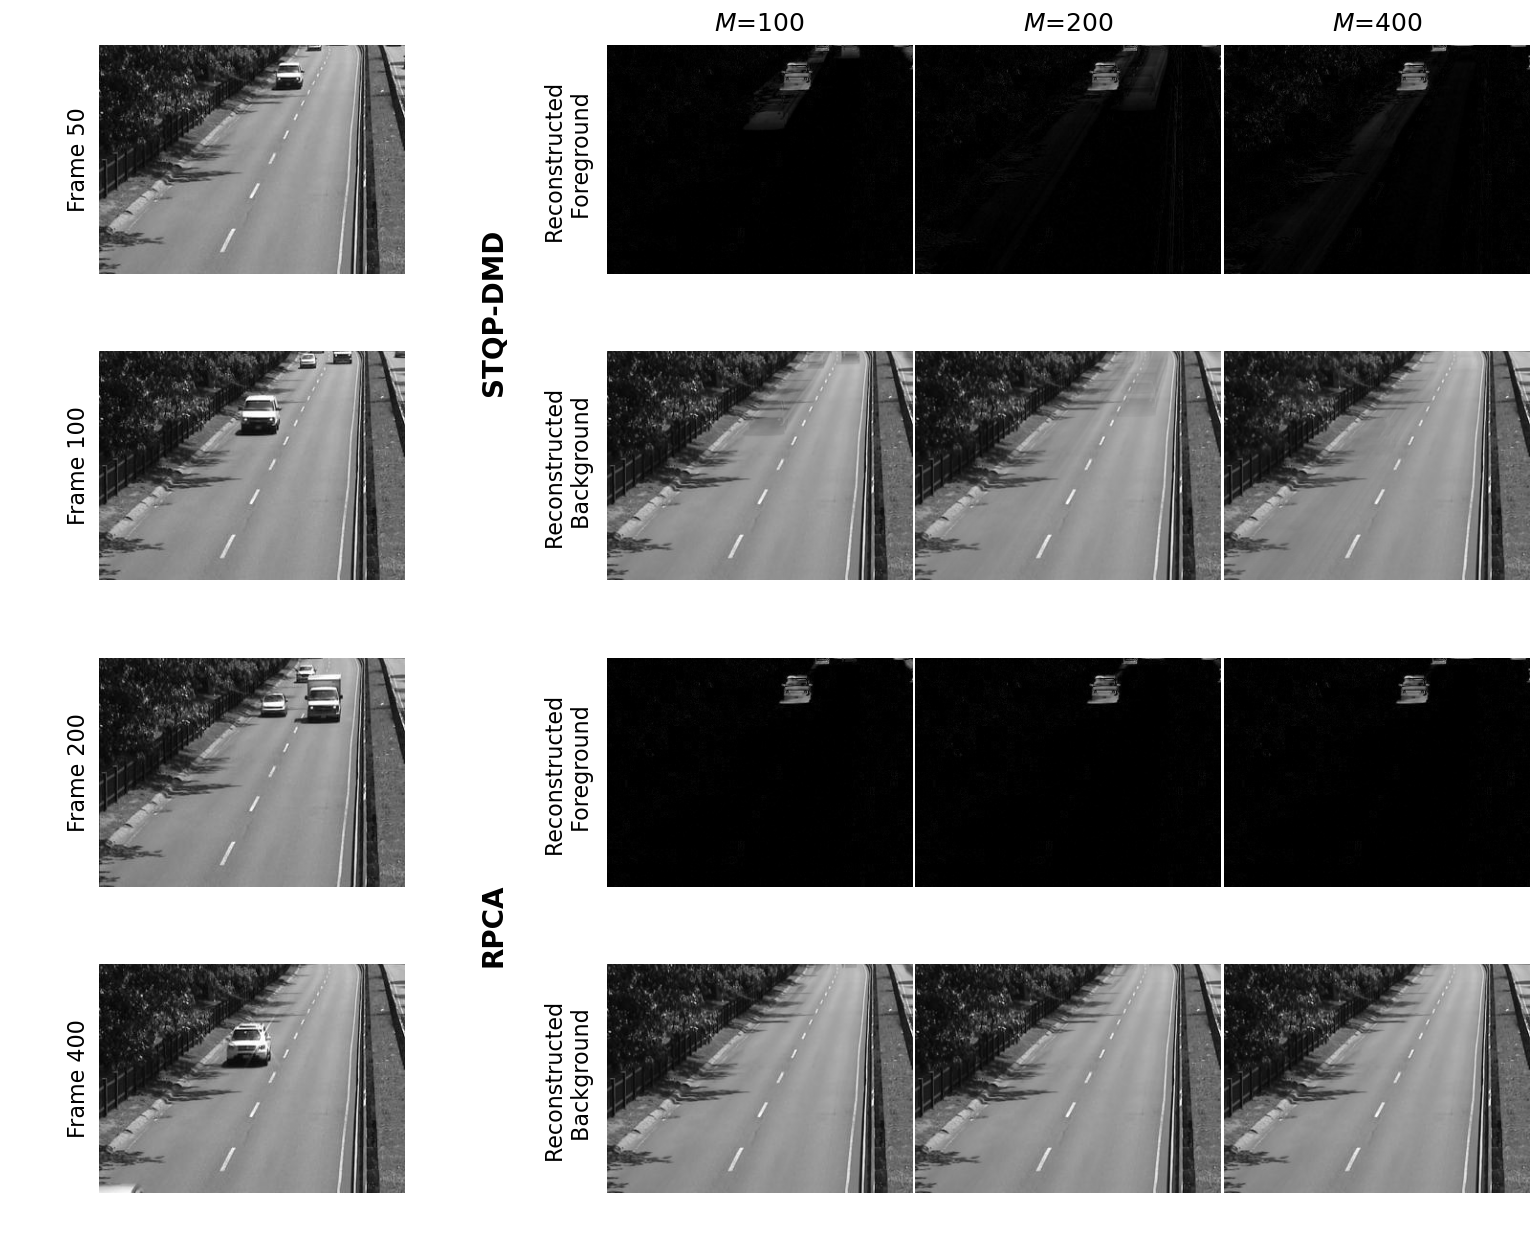

In [7]:
frame_id = 49
vmin, vmax = 0, 1
# Original frames
frame_indices = [49, 99, 199, 399]
frame_labels = [50, 100, 200, 400]
# Methods and components for the right figure
method_keys = [
    ('amp', 'fg_video'),    # STQP-DMD - Foreground
    ('amp', 'bg_video'),    # STQP-DMD - Background
    ('rpca', 'fg_video'),   # RPCA - Foreground
    ('rpca', 'bg_video')    # RPCA - Background
]
M_values = [100, 200, 400]
row_labels = ['Reconstructed \n Foreground','Reconstructed \n Background',
              'Reconstructed \n Foreground','Reconstructed \n Background']

fig = plt.figure(figsize=(16, 14))

gs = fig.add_gridspec(4, 7,left=0.035,right=0.985,top=0.92,bottom=0.05,
    width_ratios=[
        0.28,   # Frame labels
        1.00,   # Original images
        0.25,   # STQP-DMD / RPCA
        0.38,   # Foreground / Background
        1.00,   # M=100
        1.00,   # M=200
        1.00    # M=400
    ],
    wspace=0.015,
    hspace=0.025)

original_axes = []
for row_idx, (frame_idx, label) in enumerate(
        zip(frame_indices, frame_labels)):
    # Frame label
    ax_frame = fig.add_subplot(gs[row_idx, 0])
    ax_frame.axis('off')
    ax_frame.text(0.80,0.5,f"Frame {label}",fontsize=16,rotation=90,va='center',ha='center')
    # Original image
    ax_orig = fig.add_subplot(gs[row_idx, 1])
    ax_orig.imshow(test_video[frame_idx],cmap="gray",vmin=vmin,vmax=vmax)
    ax_orig.axis('off')
    original_axes.append(ax_orig)

result_axes = []
for row_idx, (method_key, video_key) in enumerate(method_keys):
    row_axes = []
    for col_idx, M in enumerate(M_values):
        ax = fig.add_subplot(gs[row_idx, col_idx + 4])
        data = results[method_key][M][video_key][frame_id]
        ax.imshow(data,cmap="gray",vmin=vmin,vmax=vmax)
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(f'$M$={M}',fontsize=18,pad=10)
        row_axes.append(ax)
    result_axes.append(row_axes)

for row_idx, label in enumerate(row_labels):
    ax_temp = fig.add_subplot(gs[row_idx, 3])
    pos = ax_temp.get_position()
    ax_temp.remove()
    x_center = pos.x0 + pos.width / 2+0.015
    image_pos = result_axes[row_idx][0].get_position()
    y_center = image_pos.y0 + image_pos.height / 2
    fig.text(x_center,y_center,label,fontsize=16,rotation=90,va='center',ha='center',)

ax_temp = fig.add_subplot(gs[0:2, 2])
pos = ax_temp.get_position()
ax_temp.remove()
stqp_x_center = pos.x0 + pos.width / 2
pos_row0 = result_axes[0][0].get_position()
pos_row1 = result_axes[1][0].get_position()
stqp_y_center = (pos_row0.y0 + pos_row1.y1) / 2

fig.text(stqp_x_center+0.03,stqp_y_center,'STQP-DMD',fontsize=20,rotation=90,va='center',ha='center',fontweight='bold')
ax_temp = fig.add_subplot(gs[2:4, 2])
pos = ax_temp.get_position()
ax_temp.remove()
rpca_x_center = pos.x0 + pos.width / 2
pos_row2 = result_axes[2][0].get_position()
pos_row3 = result_axes[3][0].get_position()
rpca_y_center = (pos_row2.y0 + pos_row3.y1) / 2

fig.text(rpca_x_center+0.03,rpca_y_center,'RPCA',fontsize=20,rotation=90,va='center',ha='center',fontweight='bold')
plt.show()